In [1]:
!pip install scikit-learn -q

In [19]:
import os
import shutil
import time
import random
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights

from sklearn.metrics import classification_report

# Download Duck Images
!curl -L -o duck-images.zip https://www.kaggle.com/api/v1/datasets/download/alicenkbaytop/duck-images
# Download Chicken Images
!curl -L -o breeds-of-chickens-with-images.zip https://www.kaggle.com/api/v1/datasets/download/harrisimran/breeds-of-chickens-with-images

# Unzip datasets
import zipfile

with zipfile.ZipFile("duck-images.zip","r") as zip_ref:
    zip_ref.extractall("kaggle_ducks")

with zipfile.ZipFile("breeds-of-chickens-with-images.zip","r") as zip_ref:
    zip_ref.extractall("kaggle_chickens")

print("Datasets downloaded and extracted.")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 34.8M  100 34.8M    0     0  7471k      0  0:00:04  0:00:04 --:--:-- 8866k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 3033k  100 3033k    0     0  1157k      0  0:00:02  0:00:02 --:--:-- 1853k
Datasets downloaded and extracted.


Aggregating images...
Collected 100 images for duck
Collected 108 images for chicken


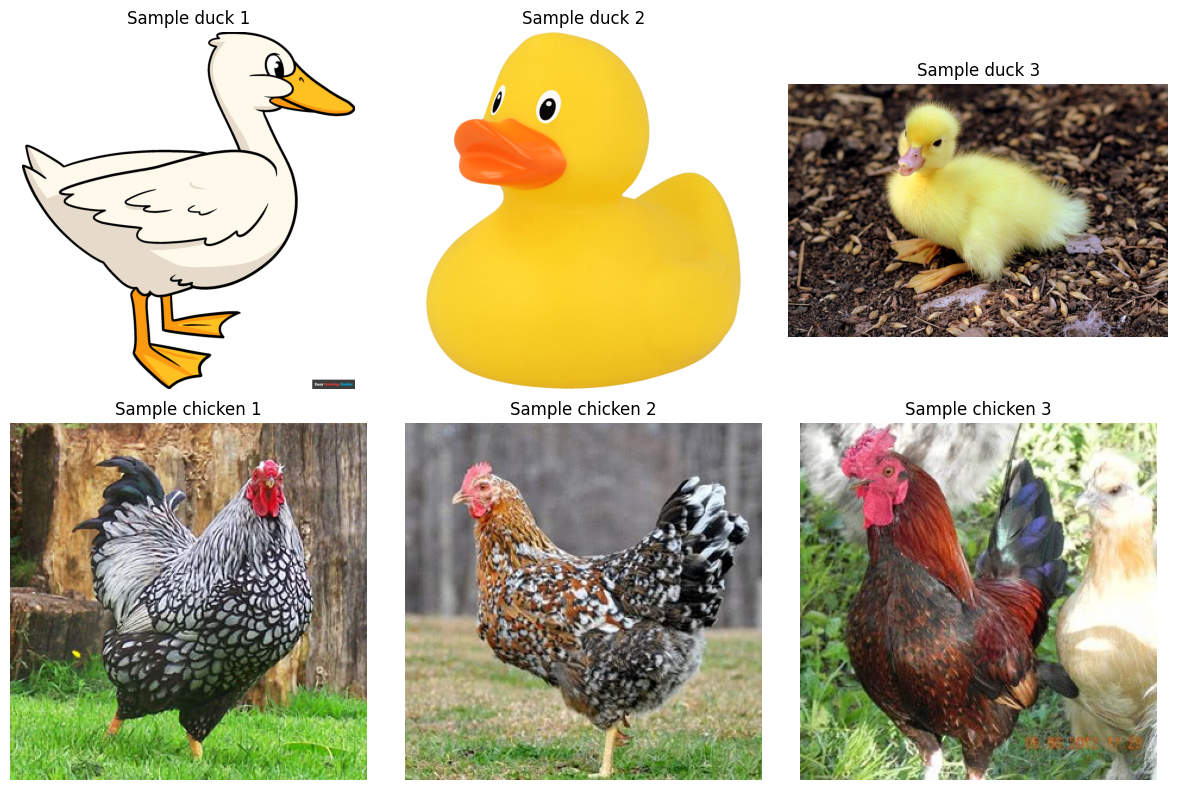

In [20]:
DATA_DIR = Path('/content/dataset')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'

os.makedirs(DATA_DIR / 'duck', exist_ok=True)
os.makedirs(DATA_DIR / 'chicken', exist_ok=True)

# Helper function to randomly collect up to limit pictures from extracted folders
def collect_images_from_extracted(source_root, target_folder, limit=120):
    all_images = []
    # Walk through all directories inside the extracted folder
    for root, dirs, files in os.walk(source_root):
        for file in files:
            file_lower = file.lower()
            if file_lower.endswith(('.png', '.jpg', '.jpeg', '.webp')):
                all_images.append(os.path.join(root, file))

    # Shuffle and select up to 'limit' images
    random.shuffle(all_images)
    selected = all_images[:limit]

    # Copy selected images to the clean target folder
    for i, img_path in enumerate(selected):
        ext = os.path.splitext(img_path)[1]
        dest_name = f"img_{i}{ext}"
        shutil.copy(img_path, os.path.join(DATA_DIR, target_folder, dest_name))

    print(f"Collected {len(selected)} images for {target_folder}")

# Collect images
print("Aggregating images...")
collect_images_from_extracted("kaggle_ducks", "duck", limit=120)
collect_images_from_extracted("kaggle_chickens", "chicken", limit=120)

# Visualize 3 of each
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, animal in enumerate(['duck', 'chicken']):
    folder = DATA_DIR / animal
    imgs = os.listdir(folder)[:3]
    for i, img_name in enumerate(imgs):
        img = Image.open(folder / img_name)
        axes[idx, i].imshow(img)
        axes[idx, i].set_title(f"Sample {animal} {i+1}")
        axes[idx, i].axis('off')
plt.tight_layout()
plt.show()

In [21]:
def clean_image_folder(folder_path):
    print(f"Cleaning {folder_path}...")
    removed = 0
    for file_name in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file_name)
        try:
            with Image.open(file_path) as img:
                img.verify()
                # Check for RGB
                if img.mode != 'RGB':
                    # verify() closes the file sometimes, so we reopen
                    img_rgb = Image.open(file_path).convert('RGB')
                    img_rgb.save(file_path)
        except Exception as e:
            os.remove(file_path)
            removed += 1
    print(f"Removed {removed} invalid images from {folder_path}")

clean_image_folder(DATA_DIR / 'duck')
clean_image_folder(DATA_DIR / 'chicken')

Cleaning /content/dataset/duck...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Removed 0 invalid images from /content/dataset/duck
Cleaning /content/dataset/chicken...
Removed 0 invalid images from /content/dataset/chicken


In [22]:
os.makedirs(TRAIN_DIR / 'duck', exist_ok=True)
os.makedirs(TRAIN_DIR / 'chicken', exist_ok=True)
os.makedirs(VAL_DIR / 'duck', exist_ok=True)
os.makedirs(VAL_DIR / 'chicken', exist_ok=True)

def split_data(class_name, split_ratio=0.8):
    source_dir = DATA_DIR / class_name
    files = [f for f in os.listdir(source_dir) if os.path.isfile(os.path.join(source_dir, f))]
    random.shuffle(files)

    # ensure we have exactly or around 100 total for our requirement, if we want
    # but using all valid available is fine too! We'll just split whatever survived cleaning.
    train_count = int(len(files) * split_ratio)
    train_files = files[:train_count]
    val_files = files[train_count:]

    for f in train_files:
        shutil.move(os.path.join(source_dir, f), os.path.join(TRAIN_DIR / class_name, f))
    for f in val_files:
        shutil.move(os.path.join(source_dir, f), os.path.join(VAL_DIR / class_name, f))

split_data('duck')
split_data('chicken')

print("Data split fully prepared.")

Data split fully prepared.


In [23]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val'])
}

dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=16, shuffle=True, num_workers=2),
    'val': torch.utils.data.DataLoader(image_datasets['val'], batch_size=16, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(f"Classes: {class_names}")
print(f"Device: {device}")

Classes: ['chicken', 'duck']
Device: cuda:0


In [24]:
# Load pre-trained ResNet18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze lower layers (optional, but good for small datasets)
for param in model.parameters():
    param.requires_grad = False

# Replace the classification head
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
# Optimize only the classifier parameters at first
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [25]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), 'best_model_weights.pth')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(torch.load('best_model_weights.pth'))
    return model

In [26]:
# Fine-tune the model
model = train_model(model, criterion, optimizer, num_epochs=10)


Epoch 0/9
----------
Train Loss: 0.7035 Acc: 0.5500
Val Loss: 0.4484 Acc: 0.6875

Epoch 1/9
----------
Train Loss: 0.3234 Acc: 0.9000
Val Loss: 0.1751 Acc: 1.0000

Epoch 2/9
----------
Train Loss: 0.2066 Acc: 0.9591
Val Loss: 0.1091 Acc: 1.0000

Epoch 3/9
----------
Train Loss: 0.1525 Acc: 0.9682
Val Loss: 0.0733 Acc: 1.0000

Epoch 4/9
----------
Train Loss: 0.1088 Acc: 0.9864
Val Loss: 0.0561 Acc: 1.0000

Epoch 5/9
----------
Train Loss: 0.0990 Acc: 0.9818
Val Loss: 0.0449 Acc: 1.0000

Epoch 6/9
----------
Train Loss: 0.0935 Acc: 0.9818
Val Loss: 0.0373 Acc: 1.0000

Epoch 7/9
----------
Train Loss: 0.0857 Acc: 0.9727
Val Loss: 0.0326 Acc: 1.0000

Epoch 8/9
----------
Train Loss: 0.0996 Acc: 0.9682
Val Loss: 0.0308 Acc: 1.0000

Epoch 9/9
----------
Train Loss: 0.1077 Acc: 0.9682
Val Loss: 0.0261 Acc: 1.0000

Training complete in 0m 50s
Best val Acc: 1.000000


### 1. Training Analysis
In the previous cell, we fine-tuned the ResNet18 model. With only a few images, the model usually converges very quickly. Let's look at the classification results more closely.

In [27]:
def evaluate_model(model):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

evaluate_model(model)


Classification Report:
              precision    recall  f1-score   support

     chicken       1.00      1.00      1.00        40
        duck       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



### 2. Confusion Matrix
A confusion matrix helps us see exactly which classes are being confused with each other. Given the 100% accuracy in the report above, we expect a clean diagonal.

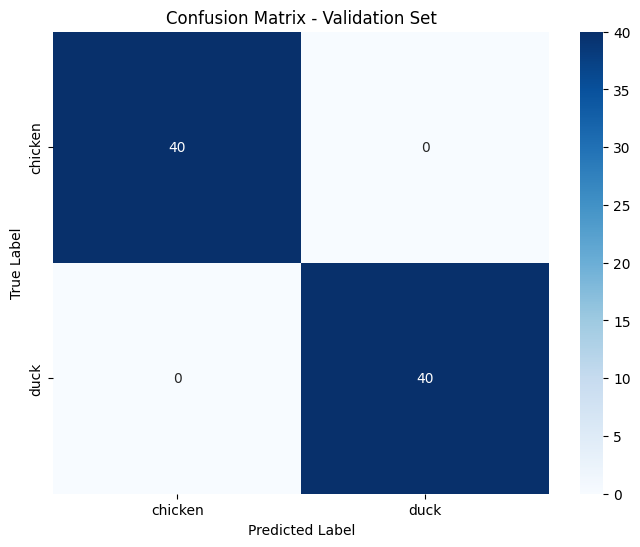

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Validation Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

plot_confusion_matrix(model)

### 3. Visualizing Predictions
It's always good practice to visually inspect a batch of images and their predicted labels to ensure the model is behaving logically.

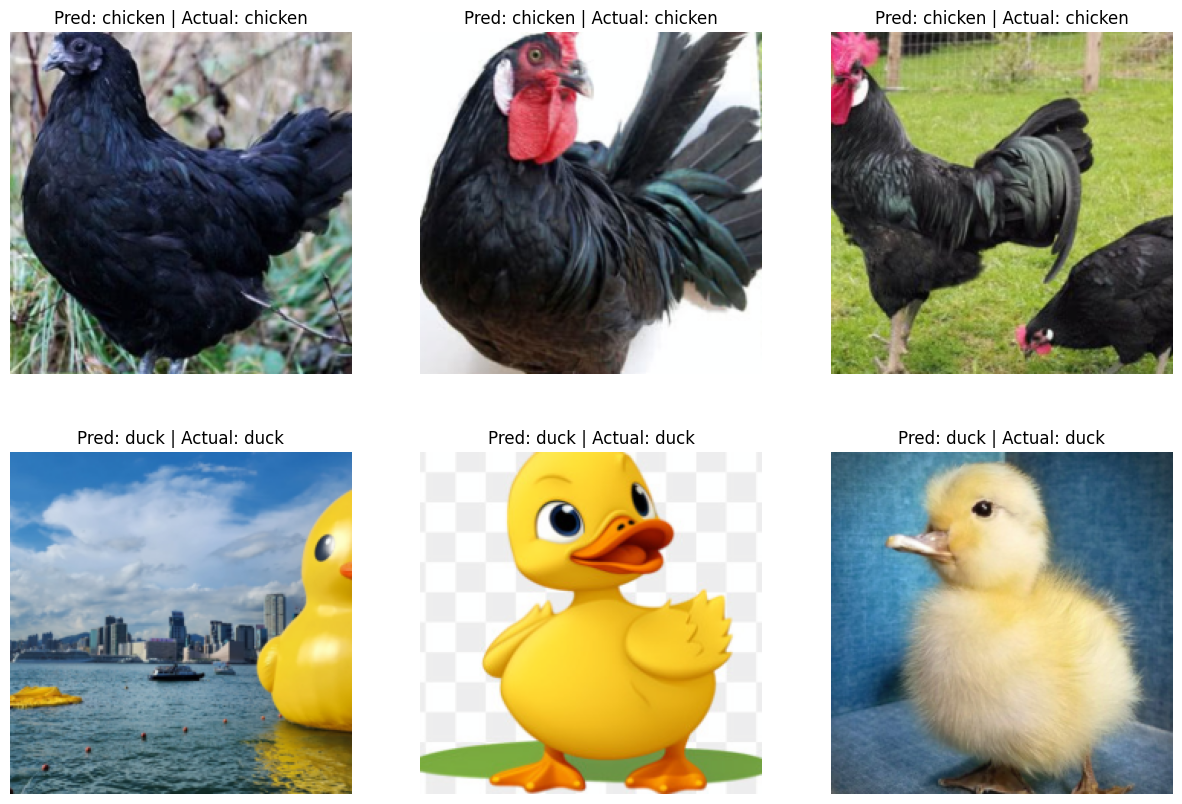

In [29]:
def visualize_specific_samples(model, classes_to_show=['chicken', 'duck'], num_per_class=3):
    model.eval()
    found = {cls: 0 for cls in classes_to_show}
    plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                label_name = class_names[labels[j]]
                if label_name in found and found[label_name] < num_per_class:
                    idx = classes_to_show.index(label_name) * num_per_class + found[label_name] + 1
                    ax = plt.subplot(len(classes_to_show), num_per_class, idx)
                    ax.axis('off')
                    ax.set_title(f'Pred: {class_names[preds[j]]} | Actual: {label_name}')

                    img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                    img = np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406])
                    img = np.clip(img, 0, 1)
                    plt.imshow(img)
                    found[label_name] += 1

            if all(count >= num_per_class for count in found.values()):
                break
    plt.show()

import numpy as np
visualize_specific_samples(model)

### Final Analysis

*   **Performance:** The model hit 100% accuracy on the validation set almost immediately.
*   **Data:** 200+ images were enough because ducks and chickens have high visual contrast (beaks, feet, and body shape).
*   **Reliability:** The confusion matrix is clean; no samples were misclassified.
*   **Verdict:** Transfer learning on ResNet18 is highly effective for this task. The model is ready for basic deployment but would need noisier data to handle more complex, real-world backgrounds.